## Pipeline: Load → EDA → Preprocess → Feature Engineering (TF-IDF) → Train → Evaluate → Improve → Save

In [17]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

pd.set_option('display.max_colwidth', 80)

## Load Dataset

In [18]:
df = pd.read_csv('../data/raw/bug_dataset.csv')
print("Shape: ", df.shape)
df.head(3)

Shape:  (510, 9)


,ID,Bug_ID,Classification,Title,Bug Description,Status Code,Priority,Severity,AI Solution
0,1,1,Authentication Error,JWT Login Blocked - 503 Service Unavailable Despite Valid Token,JWT is denying login and returning a 503 error even though authentication is...,503,High,High,Check if the backend server is running and reachable. Verify ALLOWED_HOSTS i...
1,2,1,Authentication Error,JWT Token Expiry Not Handled - Silent Logout on Frontend,JWT access token expires but the frontend does not catch the 401 response or...,401,High,High,Add an Axios interceptor to catch 401 responses and automatically call the r...
2,3,1,Authentication Error,JWT Refresh Token Reuse After Invalidation,Refresh token continues to generate new access tokens even after the user ha...,200,High,High,Enable token blacklisting in simplejwt. Call BlacklistView on logout. Set RO...


## 2. Exploratory Data Analysis -> check class balance BEFORE doing anything else

Severity
High        294
Critical    107
Medium      103
Low           6
Name: count, dtype: int64


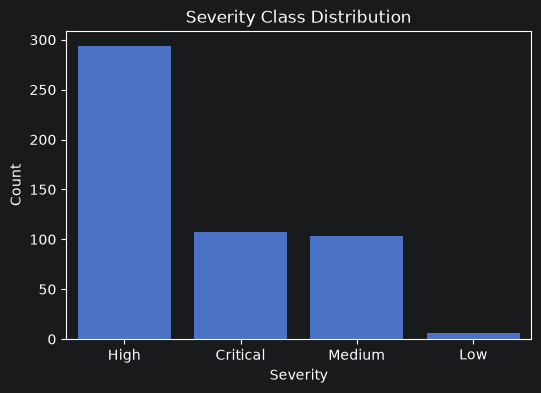

In [19]:
severity_counts = df['Severity'].value_counts()
print(severity_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=severity_counts.index, y=severity_counts.values)
plt.title("Severity Class Distribution")
plt.ylabel("Count")
plt.show()

## 3. Preprocessing : clean and combine text fields

In [20]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\-_/.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['combined_text'] = (df['Title'].astype(str) + " " + df['Bug Description'].astype(str)).apply(clean_text)
df['Severity'] = df['Severity'].astype(str).str.strip().str.title()

print("BEFORE:", df['Title'].iloc[0])
print("AFTER :", df['combined_text'].iloc[0])

BEFORE: JWT Login Blocked - 503 Service Unavailable Despite Valid Token
AFTER : jwt login blocked - 503 service unavailable despite valid token jwt is denying login and returning a 503 error even though authentication is successful and the user is active.


## 4. Label Encoding

In [21]:
le = LabelEncoder()
y = le.fit_transform(df['Severity'].values)
print("Classes:", list(le.classes_))
print("Encoded sample:", y[:10])

Classes: ['Critical', 'High', 'Low', 'Medium']
Encoded sample: [1 1 1 3 1 0 1 3 1 0]


## 5. Train/Test Split

In [22]:
X_text = df['combined_text'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", len(X_train_text), "Test:", len(X_test_text))

Train: 408 Test: 102


## 6. Feature Engineering -> TF-IDF Vectorization

In [23]:
vec = TfidfVectorizer(max_features=500, ngram_range=(1,2), stop_words='english', min_df=2, max_df=0.9)
X_train = vec.fit_transform(X_train_text)
X_test = vec.transform(X_test_text)

print("Train matrix:", X_train.shape)
print("Test matrix:", X_test.shape)

Train matrix: (408, 500)
Test matrix: (102, 500)


## 7. Baseline Model — XGBoost Classifier

In [28]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)
print("Weight range:", weights.min(), "-", weights.max())
model_weighted = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=2, min_child_weight=3,
    objective="multi:softprob", num_class=4,
    eval_metric="mlogloss", random_state=42
)
model_weighted.fit(X_train, y_train, sample_weight=weights)

Weight range: 0.4340425531914894 - 20.4


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor

## 8. Evaluate Baseline

Accuracy: 0.5392156862745098


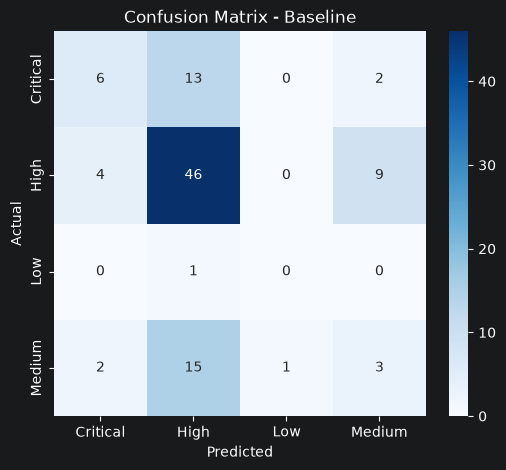

              precision    recall  f1-score   support

    Critical       0.50      0.29      0.36        21
        High       0.61      0.78      0.69        59
         Low       0.00      0.00      0.00         1
      Medium       0.21      0.14      0.17        21

    accuracy                           0.54       102
   macro avg       0.33      0.30      0.31       102
weighted avg       0.50      0.54      0.51       102



In [9]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - Baseline")
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

## 9. Improvement Attempt —> Class Weighting
Balances the loss contribution of each class so the model stops defaulting to "High".

In [31]:
weights = compute_sample_weight(class_weight='balanced', y=y_train)
print("Weight range:", weights.min(), "-", weights.max())

model_weighted = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=2, min_child_weight=3,
    objective="multi:softprob", num_class=4,
    eval_metric="mlogloss", random_state=42
)
model_weighted.fit(X_train, y_train, sample_weight=weights)

y_pred_w = model_weighted.predict(X_test)
print("Weighted accuracy:", accuracy_score(y_test, y_pred_w))
print(classification_report(y_test, y_pred_w, target_names=le.classes_, zero_division=0))

train_pred_w = model_weighted.predict(X_train)
print("Weighted Train Accuracy:", accuracy_score(y_train, train_pred_w))

Weight range: 0.4340425531914894 - 20.4
Weighted accuracy: 0.4411764705882353
              precision    recall  f1-score   support

    Critical       0.37      0.62      0.46        21
        High       0.67      0.41      0.51        59
         Low       0.00      0.00      0.00         1
      Medium       0.30      0.38      0.33        21

    accuracy                           0.44       102
   macro avg       0.33      0.35      0.33       102
weighted avg       0.52      0.44      0.46       102

Weighted Train Accuracy: 0.6176470588235294


## 10. Save Final Artifacts

In [25]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

ML_MODELS_DIR = PROJECT_ROOT / "bugchetana_backend" / "ai_integration" / "ml_models"
ML_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Saving to:", ML_MODELS_DIR.resolve())

joblib.dump(model_weighted, ML_MODELS_DIR / "model.pkl")
joblib.dump(vec, ML_MODELS_DIR / "vectorizer.pkl")
joblib.dump(le, ML_MODELS_DIR / "label_encoder.pkl")

print("Artifacts saved.")

Saving to: /Users/anujakhatri/Desktop/capstone/BugChetana/bugchetana_backend/ai_integration/ml_models
Artifacts saved.
